# 分析の手習い — 解答確認用

架空のHPLC・生薬分析データで学ぶPython。サイトと同じ順序・演習IDです。各章の準備セルから始められます。初めての方はPREP-01から読みましょう。

測定値は学習用の式で生成したものです。実際の分析法、成分の効能、規格適合を判断する教材ではありません。

## 目次

- 最小限の準備：PREP-01
- pandas：PD-01 / PD-02 / PD-03 / PD-04 / PD-05
- NumPy：NP-01 / NP-02 / NP-03
- Matplotlib：MPL-01 / MPL-02 / MPL-03
- seaborn：SNS-01 / SNS-02 / SNS-03
- scikit-learn：ML-01 / ML-02 / ML-03 / ML-04 / ML-05 / ML-06
- 総合演習：ALL-01 / ALL-02 / ALL-03

## 0. 最小限の準備

この章の準備セルを最初に実行してください。前の章の回答は使いません。例題は実行して変更する見本、演習は自分で書く問題です。

In [1]:
from IPython.display import display
from learning import check_answer

### PREP-01　セルを動かして、保存する

目安：20分 / 前提：Pythonで変数に値を入れた経験が少しある

#### 学習目標

- JupyterLabでNotebookを開く
- 実行順と保存・再起動の違いを説明する

まずサイトの「環境構築とJupyterLab」またはREADMEに従って、教材フォルダでJupyterLabを起動します。初回だけPythonライブラリを導入すれば、以降はオフラインで使えます。左のファイル一覧から `exercises.ipynb` を開きましょう。

Notebookは文章やコードを「セル」という小さな区画に分けたファイルです。コードセルを選んで **Shift+Enter** を押すと、Pythonを実行する仕組みであるカーネルへコードを送ります。`=` は右の値に名前を付け、`print()` は値を表示します。例題を実行し、120を180に変えてもう一度動かしてください。

保存はCmd+S / Ctrl+S。保存したコードと、カーネルが覚えている変数は別です。Kernelメニューで再起動すると変数は消えます。画面の上にあるセルが先に実行されるとは限りません。実行番号を確認し、章の準備セルから下へ順番に実行します。「Restart Kernel and Run All Cells」で先頭から再現できるかも確認できます。未回答の演習は `None`（まだ値がない印）のままで構いません。

#### 例題（演習とは条件が異なります）

In [2]:
seconds = 120
minutes = seconds / 60
print(minutes)

2.0


120秒は2分です。再起動した後に計算セルだけを実行すると、secondsが未定義になる理由を考えましょう。

#### よくある間違い

- 保存すれば変数も復元すると思う
- 下のセルを先に動かし、古い変数を使う

### 演習 PREP-01

90秒を分に直し、数値をprep_01に入れて表示してください。求める単位は分です。

使用データ：この演習はCSVを使いません。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

1分は60秒です。

</details>

<details><summary>ヒント2</summary>

秒の値を60で割ります。

</details>

In [3]:
prep_01 = 90 / 60
print(prep_01)

1.5


#### 考え方と結果の読み取り

90を60で割るので1.5分です。コードの実行とファイルの保存は別の操作です。変更したら保存してください。

In [4]:
from learning import check_answer
check_answer('PREP-01', globals().get('prep_01'))

PREP-01：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- 保存と再起動で何が残り、何が消えるか
- 例題の値を変え、実行結果が変わったか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

## 1. pandas

この章の準備セルを最初に実行してください。前の章の回答は使いません。例題は実行して変更する見本、演習は自分で書く問題です。

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display
from learning import check_answer
df = pd.read_csv('data/hplc.csv')
analytes = pd.read_csv('data/analytes.csv')
Path('outputs').mkdir(exist_ok=True)


### PD-01　CSVを開き、生薬別に集計する

目安：25分 / 前提：PREP-01のセル操作

#### 学習目標

- 先頭5行を確認する
- 特定の生薬を抽出する
- 生薬別の平均成分量を求める

最初は、表の中身を確かめるところから始めます。HPLCは成分を分けて検出する分析です。このCSVでは1行が独立した検体の1成分の測定、1列が生薬名や成分量などの項目です。数値は学習用に作った架空データです。

`import pandas as pd` は表を扱うライブラリpandasを読み込み、短い名前pdで呼ぶ指定です。`read_csv()`で列名付きの表 **DataFrame** を作ります。`head(5)`で先頭5行を見て、予想した列名と単位かを確認します。`df['herb']`のように1列を取り出すと **Series** になります。

`==` は等しいかを調べる記号です。`df['herb'] == 'ショウキョウ'`は行ごとのTrue/Falseになり、それを角括弧へ入れると条件に合う行だけ残ります。`groupby('herb')`は生薬別に行をまとめ、`['content_mg_g'].mean()`は各組の記録済み成分量の平均を計算します。欠損値は平均から除かれるため、件数にも注目してください。

例題を動かしたら、生薬名を変えて結果を見比べましょう。別の生薬では別の成分を測っており、mg/gの大小を薬効の優劣とは解釈できません。

#### 例題（演習とは条件が異なります）

In [6]:
import pandas as pd
df = pd.read_csv('data/hplc.csv')
display(df.head(5))
display(df[df['herb'] == 'ショウキョウ'].head(5))
display(df.groupby('herb')['content_mg_g'].mean())

,sample_id,herb,analyte,instrument,temperature,flow,acn,peak_area,content_mg_g,retention_min,resolution
0,S0001,ショウキョウ,6-gingerol,LC-B,40.5,0.97,35.3,73609.0,7.317,7.825,1.350
1,S0002,カンゾウ,グリチルリチン,LC-A,33.8,0.56,33.7,86957.0,8.755,18.188,1.541
2,S0003,オウゴン,バイカリン,LC-A,42.2,0.56,25.7,148784.0,14.646,21.500,1.504
3,S0004,ショウキョウ,6-gingerol,LC-B,38.9,0.54,44.2,63652.0,6.364,12.362,1.546
4,S0005,カンゾウ,グリチルリチン,LC-B,26.9,0.83,27.1,105867.0,10.432,14.155,1.535


,sample_id,herb,analyte,instrument,temperature,flow,acn,peak_area,content_mg_g,retention_min,resolution
0,S0001,ショウキョウ,6-gingerol,LC-B,40.5,0.97,35.3,73609.0,7.317,7.825,1.350
3,S0004,ショウキョウ,6-gingerol,LC-B,38.9,0.54,44.2,63652.0,6.364,12.362,1.546
6,S0007,ショウキョウ,6-gingerol,LC-A,40.2,0.89,29.9,82007.0,8.102,9.557,1.330
9,S0010,ショウキョウ,6-gingerol,LC-B,34.0,0.95,35.3,68296.0,6.823,8.917,1.388
12,S0013,ショウキョウ,6-gingerol,LC-B,37.9,0.68,27.2,95999.0,9.635,13.610,1.835


herb
オウゴン      15.941319
カンゾウ      12.087275
ショウキョウ     7.900219
Name: content_mg_g, dtype: float64

最初の表は全体の先頭5行、次の表はショウキョウだけの先頭5行です。最後のSeriesは生薬名が見出し、平均成分量mg/gが値です。

#### よくある間違い

- 比較に=を使う。等しいかを調べるのは==
- 先頭5行だけを全件だと思う

### 演習 PD-01

カンゾウだけを抽出し、その全行と平均成分量mg/gをpd_01に辞書でまとめてください。辞書は名前と値の組を{キー: 値}で保持します。キーはrows（抽出表）とmean_content（平均値）とします。抽出表は120行、herbがすべてカンゾウであることを確認してください。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

まず条件に合う表を別の変数に置きます。

</details>

<details><summary>ヒント2</summary>

平均は抽出した表のcontent_mg_g列にmean()を使います。

</details>

In [7]:
selected = df[df['herb'] == 'カンゾウ']
pd_01 = {'rows': selected, 'mean_content': selected['content_mg_g'].mean()}
display(pd_01['rows'].head())
print('行数:', len(pd_01['rows']), '平均mg/g:', pd_01['mean_content'])

,sample_id,herb,analyte,instrument,temperature,flow,acn,peak_area,content_mg_g,retention_min,resolution
1,S0002,カンゾウ,グリチルリチン,LC-A,33.8,0.56,33.7,86957.0,8.755,18.188,1.541
4,S0005,カンゾウ,グリチルリチン,LC-B,26.9,0.83,27.1,105867.0,10.432,14.155,1.535
7,S0008,カンゾウ,グリチルリチン,LC-B,40.7,0.84,26.3,124752.0,12.442,12.154,1.499
10,S0011,カンゾウ,グリチルリチン,LC-A,32.4,0.88,31.3,124471.0,12.388,12.088,1.769
13,S0014,カンゾウ,グリチルリチン,LC-B,41.5,0.66,32.7,98837.0,9.835,14.709,1.650


行数: 120 平均mg/g: 12.087275229357797


#### 考え方と結果の読み取り

全件を抽出してから平均を求めます。head()は表示を短くするために使い、平均の計算対象を先頭5件に限定しません。辞書に表と数値を入れると、意味を示すキーで取り出せます。

In [8]:
from learning import check_answer
check_answer('PD-01', globals().get('pd_01'))

PD-01：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- カンゾウの行だけになっているか
- 平均に使った列と単位を説明できるか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### PD-02　表を点検し、行と列を選ぶ

目安：30分 / 前提：PD-01

#### 学習目標

- infoとdescribeを読み取る
- locとilocで選択する
- 値で並べ替える

CSVを読めても、各列が意図した型とは限りません。`info()`は列の型と欠損でない件数を表示します。float64は小数を持つ数値、objectはこの表では主に文字列です。`describe()`は数値列の件数・平均・標準偏差・最小値・四分位点・最大値をまとめます。四分位点は小さい順に並べたデータを4等分する境界です。

複数列の名前はリスト `['herb', 'flow']` でまとめます。リストは順序付きの値の集まりです。`df[列名のリスト]`は表を返します。`loc[行のラベルまたは条件, 列名]`は名前や条件で選び、`iloc[行の位置, 列の位置]`は0から始まる位置で選びます。位置のスライス `0:3` は0,1,2を含み、終点3を含みません。locのラベル範囲は終点を含むため混同しないでください。

`sort_values()`で指定列の値を順番に並べます。`ascending=False`は降順です。最大の値から点検したいときに使います。元の表の行番号は残るので、行番号と値の順位を区別しましょう。

#### 例題（演習とは条件が異なります）

In [9]:
df.info()
display(df[['flow','retention_min']].describe())
display(df.loc[df['herb']=='ショウキョウ', ['sample_id','flow']].head(3))
display(df.iloc[0:3, 0:3])
display(df.sort_values('retention_min', ascending=False).head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sample_id      360 non-null    object 
 1   herb           360 non-null    object 
 2   analyte        360 non-null    object 
 3   instrument     360 non-null    object 
 4   temperature    342 non-null    float64
 5   flow           360 non-null    float64
 6   acn            360 non-null    float64
 7   peak_area      360 non-null    float64
 8   content_mg_g   336 non-null    float64
 9   retention_min  360 non-null    float64
 10  resolution     360 non-null    float64
dtypes: float64(7), object(4)
memory usage: 31.1+ KB


,flow,retention_min
count,360.000000,360.000000
mean,0.757778,13.492733
std,0.146257,3.443568
min,0.500000,7.101000
25%,0.640000,10.825750
50%,0.760000,13.186500
75%,0.890000,15.301500
max,1.000000,25.086000


,sample_id,flow
0,S0001,0.97
3,S0004,0.54
6,S0007,0.89


,sample_id,herb,analyte
0,S0001,ショウキョウ,6-gingerol
1,S0002,カンゾウ,グリチルリチン
2,S0003,オウゴン,バイカリン


,sample_id,herb,analyte,instrument,temperature,flow,acn,peak_area,content_mg_g,retention_min,resolution
74,S0075,オウゴン,バイカリン,LC-B,NaN,0.52,25.6,170524.0,NaN,25.086,2.039
124,S0125,カンゾウ,グリチルリチン,LC-B,25.8,0.52,26.9,129532.0,12.955,22.834,1.951
320,S0321,オウゴン,バイカリン,LC-B,43.3,0.53,26.8,167935.0,16.860,22.460,1.906


infoではtemperatureとcontent_mg_gの件数が360より少なくなります。保持時間で降順に並べた表の先頭が長い測定です。

#### よくある間違い

- ilocに列名を渡す
- sort_values()の戻り値を受け取らず元の表が変わると思う

### 演習 PD-02

flowが0.8以上の行からsample_idとflowの2列を選び、flowを降順に並べた表をpd_02に入れてください。位置による選択の復習として、結果の先頭3行をilocで表示してください。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

loc[条件, 列名のリスト]で選びます。

</details>

<details><summary>ヒント2</summary>

sort_valuesのascending=Falseを指定します。

</details>

In [10]:
pd_02 = df.loc[df['flow']>=0.8, ['sample_id','flow']].sort_values('flow',ascending=False)
display(pd_02.iloc[:3])

,sample_id,flow
183,S0184,1.0
307,S0308,1.0
167,S0168,1.0


#### 考え方と結果の読み取り

条件選択の後に並べ替えます。流速が高い順ですが、それだけで保持時間が最短とは限りません。成分や溶媒比率など、ほかの条件も異なります。

In [11]:
from learning import check_answer
check_answer('PD-02', globals().get('pd_02'))

PD-02：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- infoの非欠損件数は何を表すか
- locの名前とilocの位置の違いを説明できるか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### PD-03　列を追加し、欠損値を扱う

目安：30分 / 前提：PD-02

#### 学習目標

- 単位を変換した列を作る
- 欠損数を数える
- 補完と除外の違いを説明する

元のデータを残したまま加工すると、処理の前後を比較できます。`copy()`で表を複製し、新しい列へ計算結果を代入します。列全体に60を掛けると、各行の保持時間が分から秒へ変わります。行ごとの繰り返しを書く必要はありません。

空欄はpandasでは欠損値として扱われます。`isna()`は欠損ならTrueになり、`sum()`でその数を数えます。`dropna(subset=[列名])`は指定列が欠けた行を除外します。一方、`fillna(値)`は行を残したまま空欄を補います。中央値は値を小さい順に並べた中央の値です。代表値で補っても、本当の測定値が分かるようになったわけではありません。

ここでは表操作の練習として温度の中央値補完を試します。成分量の空欄はゼロと同じ意味ではないため、理由もなくゼロで埋めません。機械学習では、この段階で全件の中央値を計算してから分割してはいけません。ML章で、訓練データだけから補完値を学習する方法を扱います。

#### 例題（演習とは条件が異なります）

In [12]:
work = df.copy()
work['retention_sec'] = work['retention_min'] * 60
print('欠損数:', work[['temperature','content_mg_g']].isna().sum())
work['temperature'] = work['temperature'].fillna(work['temperature'].median())
display(work[['temperature','retention_sec']].head())
print('成分量が記録された行数:',len(df.dropna(subset=['content_mg_g'])))

欠損数: temperature     18
content_mg_g    24
dtype: int64


,temperature,retention_sec
0,40.5,469.50
1,33.8,1091.28
2,42.2,1290.00
3,38.9,741.72
4,26.9,849.30


成分量が記録された行数: 336


温度を補っても成分量の欠損は残ります。保持時間の秒表示は分表示の60倍です。補完した行と実測値を同じ確かさで扱わないようにします。

#### よくある間違い

- 欠損を測定値ゼロと取り違える
- 全列のdropnaで意図せず多くの行を消す

### 演習 PD-03

成分量content_mg_gが欠損している行だけを除き、retention_sec列を追加した表をpd_03に入れてください。元のdfを変えず、336行を残し、秒はretention_minの60倍にしてください。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

dropnaのsubsetで成分量列だけを指定します。

</details>

<details><summary>ヒント2</summary>

copy()した表へ新しい列を追加します。

</details>

In [13]:
pd_03 = df.dropna(subset=['content_mg_g']).copy()
pd_03['retention_sec'] = pd_03['retention_min'] * 60
print(pd_03.shape)
display(pd_03[['content_mg_g','retention_sec']].head())

(336, 12)


,content_mg_g,retention_sec
0,7.317,469.50
1,8.755,1091.28
2,14.646,1290.00
3,6.364,741.72
4,10.432,849.30


#### 考え方と結果の読み取り

欠損を除いた行に対して、単位変換をしています。温度の欠損はそのままでもこの計算は可能です。除外した24行が無作為とは限らない実データでは、平均の偏りにも注意が必要です。

In [14]:
from learning import check_answer
check_answer('PD-03', globals().get('pd_03'))

PD-03：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- 除外した列と残った行数を説明する
- 補完と除外で分析対象がどう変わるか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### PD-04　グループ集計とマスタ結合

目安：35分 / 前提：PD-03

#### 学習目標

- 件数と平均を一緒に集計する
- mergeの行数増加を検出する

集計値を読むときは、平均だけでなく何件の値から計算したかも確認します。`groupby()`の後の`agg()`へ辞書を渡すと、列ごとに集計方法を指定できます。辞書は `{名前: 値}` という対応表です。ここでは1列に `['count','mean']` という関数名のリストを指定します。countは欠損を除いた件数で、表の行数とは違う場合があります。

別の表の情報を追加するときは `merge()` を使います。成分名analyteを共通のキーとして、測定表へ成分類を追加します。`how='left'`は左の測定表の行を残す結合です。`validate='many_to_one'`は、測定表には同じ成分が何行あってもよいが、マスタ側では各成分を1行に限るという確認です。

マスタのキーが重複していると、1件の測定が複数行へ増えて集計を誤ることがあります。結合前後の件数と、追加した列の欠損を確認します。結合できなかったキーがあってもleft結合は成功するため、validateだけで完全な一致は保証しません。

#### 例題（演習とは条件が異なります）

In [15]:
display(df.groupby('herb').agg({'content_mg_g':['count','mean']}))
joined = df.merge(analytes,on='analyte',how='left',validate='many_to_one')
print('結合前後:',len(df),len(joined))
print('マスタ未一致:', joined['class'].isna().sum())
display(joined[['analyte','class','detection_nm']].head())

content_mg_g           
              count       mean
herb                          
オウゴン            113  15.941319
カンゾウ            109  12.087275
ショウキョウ          114   7.900219

結合前後: 360 360
マスタ未一致: 0


,analyte,class,detection_nm
0,6-gingerol,ジンゲロール類,280
1,グリチルリチン,サポニン類,254
2,バイカリン,フラボノイド類,280
3,6-gingerol,ジンゲロール類,280
4,グリチルリチン,サポニン類,254


欠損があるため平均に使った成分量の件数は生薬ごとの120行より少なくなります。マスタ結合では360行のままか、成分類が全行に付いたかを確認します。

#### よくある間違い

- マスタの重複で増えた行を元からあった測定と思う
- countを欠損込みの件数と思う

### 演習 PD-04

測定表へanalytesマスタをleft結合し、成分類classごとの保持時間retention_minの平均を求め、平均値の昇順のSeriesをpd_04に入れてください。結合にmany_to_oneの確認を付けてください。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

結合はanalyte列をキーにします。

</details>

<details><summary>ヒント2</summary>

結合した表でclassごとにまとめ、mean()の後にsort_values()を使います。

</details>

In [16]:
joined = df.merge(analytes,on='analyte',how='left',validate='many_to_one')
pd_04 = joined.groupby('class')['retention_min'].mean().sort_values()
display(pd_04)

class
ジンゲロール類    11.58890
サポニン類      13.70395
フラボノイド類    15.18535
Name: retention_min, dtype: float64

#### 考え方と結果の読み取り

結合した情報を使って集計しています。保持時間が違うのは成分類だけが原因とは限りません。この架空データでは複数の測定条件も変化しています。

In [17]:
from learning import check_answer
check_answer('PD-04', globals().get('pd_04'))

PD-04：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- 結合で行数が増えないことをどう確認するか
- 平均を因果関係と取り違えていないか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### PD-05　ピボット集計を保存して読み直す

目安：30分 / 前提：PD-04

#### 学習目標

- 2つの分類で集計する
- CSVを保存し読み直す
- 集計結果の限界を書く

生薬と装置を同時に見たいときは、行と列に分類を配置したピボット表が便利です。`pivot_table()`のindexに行の分類、columnsに列の分類、valuesに測定値、aggfuncに集計方法を指定します。単なる`pivot()`は同じ組合せに複数行あると失敗しますが、pivot_tableは平均などでまとめられます。

CSVへ書き出す `to_csv()` は既定で行のラベルも保存します。生薬名がindexに入った集計表では、`reset_index()`で通常の列へ戻し、`index=False`で余分な連番を保存しないようにします。保存先は入力データと分けたoutputsフォルダです。

保存できたかは、ファイルの存在だけでなく `read_csv()`で読み直して列名と値を確かめます。小数は保存時の表現により、ごく小さな誤差が出る場合があります。装置別の平均差が出ても、成分や条件をそろえた比較でなければ装置性能の優劣とは言えません。

#### 例題（演習とは条件が異なります）

In [18]:
pivot = df.pivot_table(index='herb',columns='instrument',values='retention_min',aggfunc='mean')
display(pivot)
pivot.reset_index().to_csv('outputs/retention_by_instrument.csv',index=False)
display(pd.read_csv('outputs/retention_by_instrument.csv'))

instrument,LC-A,LC-B
herb,,
オウゴン,14.913437,15.579347
カンゾウ,13.794275,13.581745
ショウキョウ,11.423656,11.759746


,herb,LC-A,LC-B
0,オウゴン,14.913437,15.579347
1,カンゾウ,13.794275,13.581745
2,ショウキョウ,11.423656,11.759746


同じ行のLC-AとLC-Bを比べると装置別の平均差が見えます。ただし条件の構成も異なるので、差だけで装置の偏りを断定できません。

#### よくある間違い

- index=Falseにする前に生薬名のindexを通常列へ戻し忘れる
- 平均値の差を装置の原因と断定する

### 演習 PD-05

生薬×装置の成分量content_mg_gの平均をピボット表pd_05に入れ、outputs/content_by_instrument.csvへ生薬名を通常列として保存してください。読み直して表示し、成分量が異なる理由を装置だけに帰せないことを文章セルに1文で説明してください。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

valuesをcontent_mg_g、aggfuncをmeanにします。

</details>

<details><summary>ヒント2</summary>

reset_index()してからindex=Falseで保存します。

</details>

In [19]:
pd_05 = df.pivot_table(index='herb',columns='instrument',values='content_mg_g',aggfunc='mean')
pd_05.reset_index().to_csv('outputs/content_by_instrument.csv',index=False)
display(pd.read_csv('outputs/content_by_instrument.csv'))
print('成分や測定条件の構成が異なるので、この平均差だけから装置の影響は決められない。')

,herb,LC-A,LC-B
0,オウゴン,15.961194,15.912370
1,カンゾウ,11.871081,12.372468
2,ショウキョウ,7.905614,7.894825


成分や測定条件の構成が異なるので、この平均差だけから装置の影響は決められない。


#### 考え方と結果の読み取り

平均は欠損を除いて計算されます。保存後の表にはherb列があります。値の違いに気づくことと原因を特定することは別で、因果的な説明には条件をそろえた比較などが必要です。

In [20]:
from learning import check_answer
check_answer('PD-05', globals().get('pd_05'))

PD-05：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- 保存先にherb列と2つの装置列があるか
- 欠損数や測定条件を確かめず装置差を断定していないか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

## 2. NumPy

この章の準備セルを最初に実行してください。前の章の回答は使いません。例題は実行して変更する見本、演習は自分で書く問題です。

In [21]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display
from learning import check_answer
df = pd.read_csv('data/hplc.csv')
analytes = pd.read_csv('data/analytes.csv')
Path('outputs').mkdir(exist_ok=True)


### NP-01　表から数値配列へ移す

目安：25分 / 前提：pandasの列選択

#### 学習目標

- DataFrameと配列の違いを説明する
- shape・dtype・スライスを使う

pandasは列名や行ラベルを持つ表に向き、NumPyは同じ型の値が並ぶ配列を使った数値計算に向きます。列を選んで `to_numpy()` を呼ぶと、表から配列へ移せます。変換後は列名が付いていないため、どの位置がどの項目かを自分で管理します。

`shape`は各方向の要素数です。360行2列なら `(360, 2)` と表示されます。dtypeは値の型を表し、この例では小数を扱うfloat64です。温度と流速は単位も範囲も異なるため、並べたからといって同じ意味にはなりません。

配列の `a[0,1]` は0行目1列目、`a[:3,0]`は先頭3行の0列目です。終点を含まないスライスはpandasのilocと同じです。`a[a[:,1] > 0.8]` は2列目で作った条件を行の選択に使います。`to_numpy()`の結果は元の表とメモリを共有する場合があるので、独立して変更したいときは `copy=True` を指定します。

#### 例題（演習とは条件が異なります）

In [22]:
a = df[['temperature','flow']].to_numpy(copy=True)
print('形状:',a.shape,'型:',a.dtype)
print(a[:3,0])
print(a[a[:,1]>0.8][:3])

形状: (360, 2) 型: float64
[40.5 33.8 42.2]
[[40.5   0.97]
 [26.9   0.83]
 [40.2   0.89]]


2列目はflowです。列名は配列に残らないので、列の順番を変えると同じ添字でも別の値になります。

#### よくある間違い

- 列名が配列にも残ると思う
- スライスの終点を含めて数える

### 演習 NP-01

flowとacnをこの順番でNumPy配列にし、先頭4行・両方の列をnp_01に入れてください。shapeは(4, 2)、dtypeは数値型であることを確認します。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

まず2列をリストで選び、to_numpy(copy=True)を呼びます。

</details>

<details><summary>ヒント2</summary>

行方向は[:4]で選べます。

</details>

In [23]:
np_01 = df[['flow','acn']].to_numpy(copy=True)[:4]
print(np_01, np_01.shape, np_01.dtype)

[[ 0.97 35.3 ]
 [ 0.56 33.7 ]
 [ 0.56 25.7 ]
 [ 0.54 44.2 ]] (4, 2) float64


#### 考え方と結果の読み取り

4行×2列で、0列が流速、1列がACNです。単位の情報も配列には残らないため、元の列名リストを読み合わせます。

In [24]:
from learning import check_answer
check_answer('NP-01', globals().get('np_01'))

NP-01：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- shapeのそれぞれの数字は何を数えるか
- 列名が必要な操作ならDataFrameを残した方がよいか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### NP-02　axisとブロードキャストを使う

目安：30分 / 前提：NP-01

#### 学習目標

- 軸を指定して平均を求める
- 列ごとにまとめて単位変換する

2次元配列の平均では、どの方向をまとめるかをaxisで指定します。`axis=0`は行方向をまとめて、各列の平均を返します。`axis=1`は列方向をまとめて、各行の平均を返します。温度と流速のように単位が違う2列の行平均は、計算できても意味がないので避けます。

配列同士の計算では、形状の末尾から見て同じ要素数、または一方が1なら、繰り返して計算するように扱えます。これが**ブロードキャスト**です。(360,2)の配列へ(2,)の倍率を掛けると、全行に列別の倍率が使われます。明示的な繰り返しを書かずに計算できます。

欠損値NaNが含まれる列へ普通のmeanを使うと、結果もNaNになります。`nanmean`は欠損を除いて平均を求めます。計算方法を変えるときは、欠損を無視する判断を説明しましょう。すべて欠損の列の平均はnanmeanでも求められません。

`np.array([60,1000])` はリストから2要素の配列を作る書き方です。

#### 例題（演習とは条件が異なります）

In [25]:
a = df[['retention_min','flow']].to_numpy()
converted = a * np.array([60,1000])
print('列平均（保持秒・流速µL/min）:',converted.mean(axis=0))
print('温度の欠損除外平均:',np.nanmean(df['temperature'].to_numpy()))

列平均（保持秒・流速µL/min）: [809.564      757.77777778]
温度の欠損除外平均: 34.97222222222222


倍率60は分から秒、1000はmLからµLです。axis=0の出力は2要素になり、列順に対応します。

#### よくある間違い

- 異なる単位の行平均を意味のある指標と考える
- axisの番号と出力の形を確認しない

### 演習 NP-02

カンゾウの行だけを選び、保持時間retention_minと流速flowをこの順に配列へ変え、[60, 1000]をブロードキャストして単位変換し、列平均の2要素配列をnp_02に入れてください。axis=1に変えると何が変わるか文章で説明してください。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

pandasのlocでカンゾウの行と2列を選んでから、配列にします。

</details>

<details><summary>ヒント2</summary>

結果のshapeが(2,)か確認します。

</details>

In [26]:
values = df.loc[df['herb']=='カンゾウ',['retention_min','flow']].to_numpy()
np_02 = (values * np.array([60,1000])).mean(axis=0)
print(np_02)
print('axis=1なら360行それぞれの平均になるが、異なる単位を混ぜるので解釈できない。')

[822.237      753.58333333]
axis=1なら360行それぞれの平均になるが、異なる単位を混ぜるので解釈できない。


#### 考え方と結果の読み取り

カンゾウ120行に絞った配列に、列の単位に合わせた倍率を適用します。平均の形が2要素でも、順番を取り違えれば誤った説明になります。axis=1の計算は可能ですが、この例では意味のある量にはなりません。

In [27]:
from learning import check_answer
check_answer('NP-02', globals().get('np_02'))

NP-02：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- 出力の単位は秒とµL/minになったか
- axis=1がこの例に不適切な理由を説明できるか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### NP-03　乱数で測定のばらつきを試す

目安：25分 / 前提：NP-02

#### 学習目標

- 固定シードで再現する
- 乱数の平均と理論値を区別する

乱数は、同じ手順でも値が揺れる状況を試すために使えます。ここでは保持時間に小さなノイズを加え、観測値のばらつきを模擬します。`np.random.default_rng(42)`で乱数を作る生成器を用意します。42はシードという初期値で、同じ初期値から同じ順序で呼び出すと再現できます。

`rng.normal(0, 0.1, size=5)`は平均0、標準偏差0.1の正規分布から5個の値を作ります。標準偏差はばらつきの大きさを表します。5個の標本の平均がぴったり0になるわけではありません。シードを変えると結果が変わり、同じ生成器を続けて使っても次の値へ進みます。

このノイズは実装の練習です。本当の装置の測定誤差が正規分布で、この大きさになるという根拠はありません。条件に合う値を `noise[noise > 0]` のように選ぶ操作も復習しましょう。

#### 例題（演習とは条件が異なります）

In [28]:
rng = np.random.default_rng(42)
noise = rng.normal(0,0.1,size=5)
print(noise)
print('標本平均:',noise.mean())
print('正の値:',noise[noise>0])

[ 0.03047171 -0.10399841  0.07504512  0.09405647 -0.19510352]
標本平均: -0.019905726058844588
正の値: [0.03047171 0.07504512 0.09405647]


生成する分布の平均は0でも、5個の値の平均は一般に0ではありません。再実行のたび同じ値なのは、セル冒頭で生成器を初期化しているためです。

#### よくある間違い

- 同じ生成器を続けて呼んでも最初の乱数が出ると思う
- 少数の乱数の平均が必ず指定値になると思う

### 演習 NP-03

シード7の生成器で平均0・標準偏差0.2の乱数を10個作り、正の値だけをnp_03に入れてください。全10個の平均が必ず0ではない理由を文章で説明してください。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

default_rng(7)をセルの先頭で作ります。

</details>

<details><summary>ヒント2</summary>

normalのsize=10、条件は>0です。

</details>

In [29]:
rng = np.random.default_rng(7)
noise = rng.normal(0,0.2,size=10)
np_03 = noise[noise>0]
print(np_03)
print('全10個の平均:',noise.mean())

[2.46030671e-04 5.97491075e-02 1.20287205e-02 2.68043049e-01]
全10個の平均: -0.040467878272820446


#### 考え方と結果の読み取り

分布の平均と、有限個の値から計算する標本平均は別です。正の値だけを選んだ後の平均は、もとの分布の平均を推定するものでもありません。

In [30]:
from learning import check_answer
check_answer('NP-03', globals().get('np_03'))

NP-03：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- シードを変えず再実行すると同じ結果になるか
- 正の値だけ残すことで分布がどう変わるか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

## 3. Matplotlib

この章の準備セルを最初に実行してください。前の章の回答は使いません。例題は実行して変更する見本、演習は自分で書く問題です。

In [31]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display
from learning import check_answer
df = pd.read_csv('data/hplc.csv')
analytes = pd.read_csv('data/analytes.csv')
Path('outputs').mkdir(exist_ok=True)
import matplotlib.pyplot as plt
import seaborn as sns
from learning import setup_plotting
setup_plotting()


### MPL-01　FigureとAxesで棒グラフを描く

目安：25分 / 前提：pandasのgroupby・NumPyの配列

#### 学習目標

- 図全体と描画領域を区別する
- 集計結果に軸名と単位を付ける

Figureは図全体、Axesはその中の座標軸付きの描画領域です。`fig, ax = plt.subplots()`で2つの値を受け取ります。複数の値を左辺の名前へ順番に入れる書き方です。棒グラフはカテゴリごとの量を比べるときに使います。集計してから描くと、何を比べているかを明確にできます。

棒の高さだけでは単位が分かりません。`set_xlabel()`と`set_ylabel()`で軸名と単位を入れます。`set_title()`は図の見出しです。最後の`plt.show()`で図を表示します。棒はゼロから始めると長さの比較を誤解しにくくなります。

この例の平均保持時間は異なる成分と条件が混在した結果です。図から差は見えますが、生薬だけの影響とは限りません。

例題の `ax.set(xlabel=..., ylabel=..., title=...)` は軸名とタイトルをまとめて設定する書き方です。

#### 例題（演習とは条件が異なります）

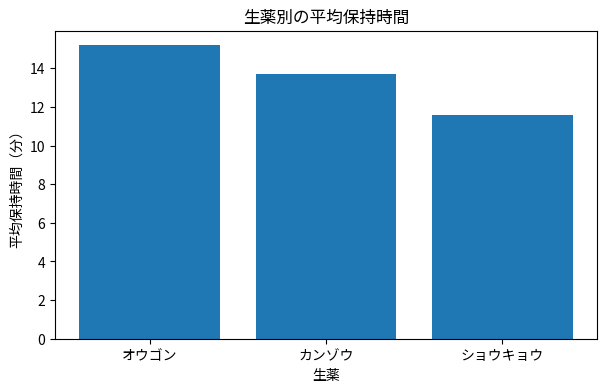

In [32]:
summary = df.groupby('herb')['retention_min'].mean()
fig, ax = plt.subplots()
ax.bar(summary.index,summary.values)
ax.set(xlabel='生薬',ylabel='平均保持時間（分）',title='生薬別の平均保持時間')
plt.show()

棒の高さは生薬別の平均保持時間です。検体数や条件の違いを踏まえて読みます。

#### よくある間違い

- 360行を集計せず同じカテゴリへ重ねて描く
- 軸の単位を書かない

### 演習 MPL-01

装置instrument別の測定件数を棒グラフにしてください。横軸に装置、縦軸に測定件数（件）、タイトルを付け、Figureをmpl_01に入れてください。2本の棒の合計が360件であることを確認します。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

groupbyのsize()は欠損に関係なく各組の行数を数えます。

</details>

<details><summary>ヒント2</summary>

fig, axのfigをmpl_01として受け取れます。

</details>

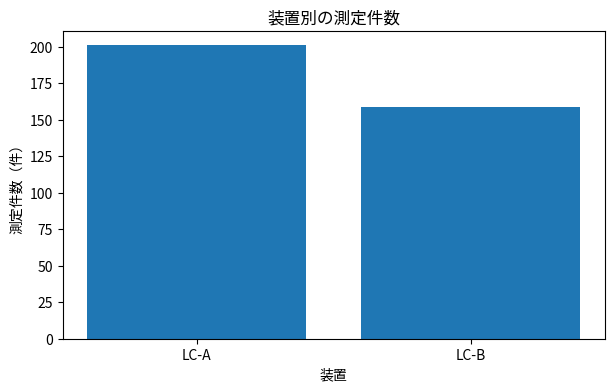

In [33]:
counts = df.groupby('instrument').size()
mpl_01, ax = plt.subplots()
ax.bar(counts.index,counts.values)
ax.set(xlabel='装置',ylabel='測定件数（件）',title='装置別の測定件数')
plt.show()

#### 考え方と結果の読み取り

棒の合計は360件です。装置によって件数が違っても、それだけで測定の良し悪しを判断できません。Figureを結果変数に持たせると、後から保存や確認ができます。

In [34]:
from learning import check_answer
check_answer('MPL-01', globals().get('mpl_01'))

MPL-01：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- 棒の合計と元の行数が一致するか
- FigureとAxesのどちらへbarを呼んだか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### MPL-02　目的に合わせて図を選ぶ

目安：35分 / 前提：MPL-01

#### 学習目標

- 散布図とヒストグラムを使い分ける
- 順序を持つ集計に折れ線を使う

2つの数値の関係を見る散布図は `scatter()`、1つの数値の分布を見るヒストグラムは `hist()`を使います。ヒストグラムのbinsは区間数で、細かくしすぎると偶然のばらつきが目立ちます。区間数を変えても残る特徴を探しましょう。

折れ線の `plot()`は点を順に結びます。このCSVの行順には時間の意味がないため、行番号順に保持時間を結んでも時間変化とは言えません。例題では流速を0.1刻みの区分へ丸め、区分ごとの平均を流速順に描きます。round(1)は小数1桁への丸めです。

散布図で傾向が見えても、成分やほかの測定条件が影響している可能性があります。軸の範囲と単位を確認し、図の形から言えることと言えないことを分けます。

`assign(flow_bin=...)` は元の表を変えず、区分の列を加えた新しい表を返します。

#### 例題（演習とは条件が異なります）

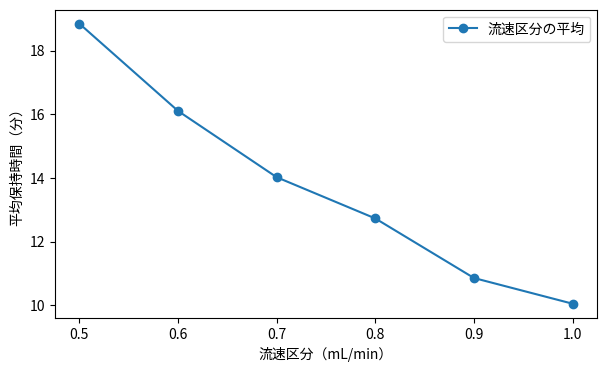

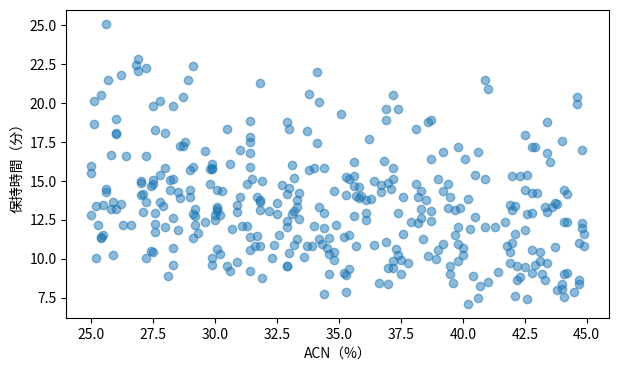

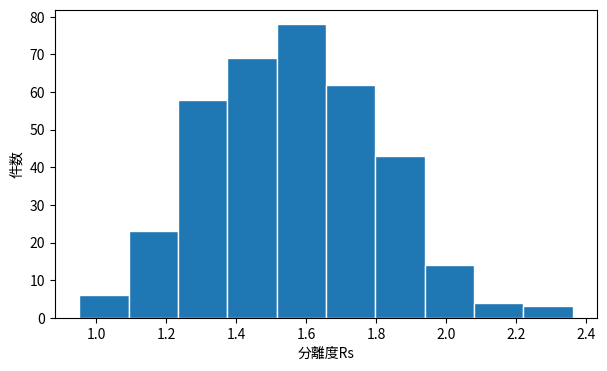

In [35]:
by_flow = df.assign(flow_bin=df['flow'].round(1)).groupby('flow_bin')['retention_min'].mean()
fig, ax = plt.subplots()
ax.plot(by_flow.index,by_flow.values,marker='o',label='流速区分の平均')
ax.set(xlabel='流速区分（mL/min）',ylabel='平均保持時間（分）')
ax.legend()
plt.show()
fig, ax = plt.subplots()
ax.scatter(df['acn'],df['retention_min'],alpha=0.5)
ax.set(xlabel='ACN（%）',ylabel='保持時間（分）')
plt.show()
fig, ax = plt.subplots()
ax.hist(df['resolution'],bins=10,edgecolor='white')
ax.set(xlabel='分離度Rs',ylabel='件数')
plt.show()

折れ線は並べた流速区分の平均を結んでいます。散布図では同じACN付近でも保持時間が広がり、ACNだけで値が決まらないことが見えます。 最後のヒストグラムは分離度の分布で、棒の高さが各区間の件数です。

#### よくある間違い

- 行順の折れ線を測定日の推移と思う
- ヒストグラムの縦軸を測定値と思う

### 演習 MPL-02

保持時間の分布を12区間のヒストグラムで描き、Figureをmpl_02に入れてください。横軸を保持時間（分）、縦軸を件数にし、棒の件数の合計と行数を比べてください。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

hist(df[列名], bins=12)を使います。

</details>

<details><summary>ヒント2</summary>

すべての保持時間が記録されているので合計は360です。

</details>

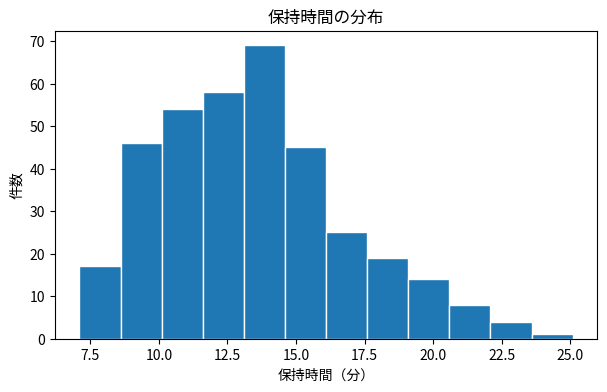

In [36]:
mpl_02, ax = plt.subplots()
ax.hist(df['retention_min'],bins=12,edgecolor='white')
ax.set(xlabel='保持時間（分）',ylabel='件数',title='保持時間の分布')
plt.show()

#### 考え方と結果の読み取り

ヒストグラムの横軸は保持時間の区間、縦軸はその区間に入った測定の件数です。ピークが複数見えても、異なる成分と条件を混ぜた分布であることを忘れないでください。

In [37]:
from learning import check_answer
check_answer('MPL-02', globals().get('mpl_02'))

MPL-02：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- binsを6や24に変えると印象は変わるか
- データの順序に意味がある図とない図を区別する

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### MPL-03　複数の図を並べて保存する

目安：30分 / 前提：MPL-02

#### 学習目標

- subplotsで図を並べる
- 凡例と日本語ラベルを付ける
- PNGを保存する

`plt.subplots(1,2)`は1行2列の描画領域を作り、axesという配列で返します。`axes[0]`と`axes[1]`へ別の図を描くと、同じ紙面で比較できます。`fig.tight_layout()`は軸名などの重なりを軽減し、`fig.savefig()`は図全体を画像へ保存します。dpiは1インチ当たりの画素数です。

複数系列の凡例には、作図時のlabelと`legend()`を使います。同じ処理を繰り返す場合の `for name in リスト:` は、値を一つずつ取り出して字下げした処理を実行する構文です。例題では2装置を同じAxesへ描きます。色に加えて凡例名や点の形でも識別できると読みやすくなります。

日本語フォントは章の準備で同梱ファイルを登録済みです。画像を開き、軸名が欠けていないかを確かめます。画面に図が出たことと、保存先へ正しい図を書けたことは別に確認しましょう。

#### 例題（演習とは条件が異なります）

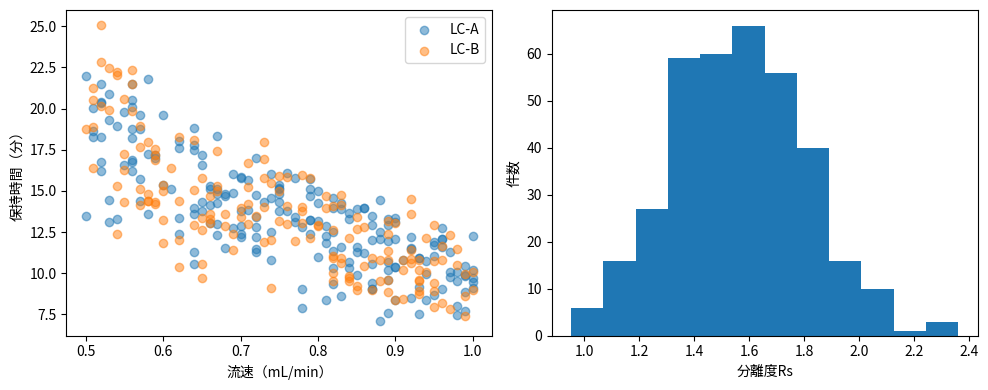

In [38]:
fig, axes = plt.subplots(1,2,figsize=(10,4))
for name in ['LC-A','LC-B']:
    part = df[df['instrument']==name]
    axes[0].scatter(part['flow'],part['retention_min'],label=name,alpha=0.5)
axes[0].set(xlabel='流速（mL/min）',ylabel='保持時間（分）')
axes[0].legend()
axes[1].hist(df['resolution'],bins=12)
axes[1].set(xlabel='分離度Rs',ylabel='件数')
fig.tight_layout()
fig.savefig('outputs/overview.png',dpi=150)
plt.show()

左は流速と保持時間の関係、右は分離度の分布です。両者の軸は別の量なので、縦の位置をそのまま対応付けません。

#### よくある間違い

- plt.savefigの時点で別のFigureを選んでしまう
- 画面表示だけを見て保存画像の欠けを確認しない

### 演習 MPL-03

1行2列の図を作り、左にACNと保持時間の散布図、右に保持時間のヒストグラムを描いてください。軸名・単位を付け、Figureをmpl_03に入れ、outputs/my_overview.pngへ保存します。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

mpl_03, axes = plt.subplots(1,2,...)とします。

</details>

<details><summary>ヒント2</summary>

各axesに描いてtight_layout後、mpl_03.savefigを使います。

</details>

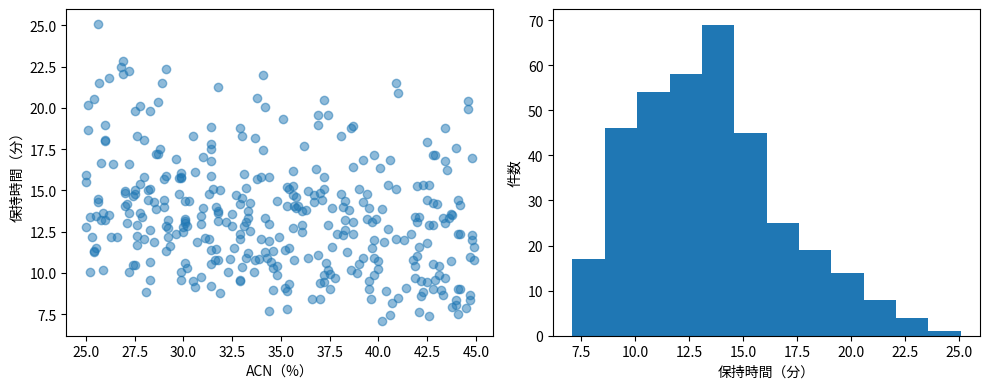

In [39]:
mpl_03, axes = plt.subplots(1,2,figsize=(10,4))
axes[0].scatter(df['acn'],df['retention_min'],alpha=0.5)
axes[0].set(xlabel='ACN（%）',ylabel='保持時間（分）')
axes[1].hist(df['retention_min'],bins=12)
axes[1].set(xlabel='保持時間（分）',ylabel='件数')
mpl_03.tight_layout()
mpl_03.savefig('outputs/my_overview.png',dpi=150)
plt.show()

#### 考え方と結果の読み取り

散布図は2変数の関係、ヒストグラムは保持時間だけの分布を示します。画像の存在は自動確認しますが、日本語の可読性や余白は画像を開いて確認してください。

In [40]:
from learning import check_answer
check_answer('MPL-03', globals().get('mpl_03'))

MPL-03：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- 保存した画像を開きラベルを読めるか
- 2つの図で答えられる問いの違いは何か

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

## 4. seaborn

この章の準備セルを最初に実行してください。前の章の回答は使いません。例題は実行して変更する見本、演習は自分で書く問題です。

In [41]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display
from learning import check_answer
df = pd.read_csv('data/hplc.csv')
analytes = pd.read_csv('data/analytes.csv')
Path('outputs').mkdir(exist_ok=True)
import matplotlib.pyplot as plt
import seaborn as sns
from learning import setup_plotting
setup_plotting()


### SNS-01　DataFrameから分布を描く

目安：25分 / 前提：MatplotlibのFigureとAxes

#### 学習目標

- 列名で作図する
- hueでグループを分ける

seabornはDataFrameの列名を指定して統計的な図を描くライブラリです。`data=df, x='retention_min'`のように書くと、列を取り出す処理を繰り返さずに使えます。`hue`は色を分ける分類列の指定で、凡例も作られます。

`histplot()`はヒストグラムを描きます。全体の分布と、生薬ごとに分けた分布を比べると、どのグループが全体の形に関わるかを見られます。ただし件数が違うグループを比較すると、棒の高さには測定件数の差も現れます。

seabornもMatplotlibのAxesに描画します。`ax=ax`で描画先を渡し、その後 `ax.set()`で日本語の軸名を設定できます。テーマを設定するとフォントも変わる場合があるため、`sns.set_theme()`の後に `setup_plotting()`を呼び直します。

#### 例題（演習とは条件が異なります）

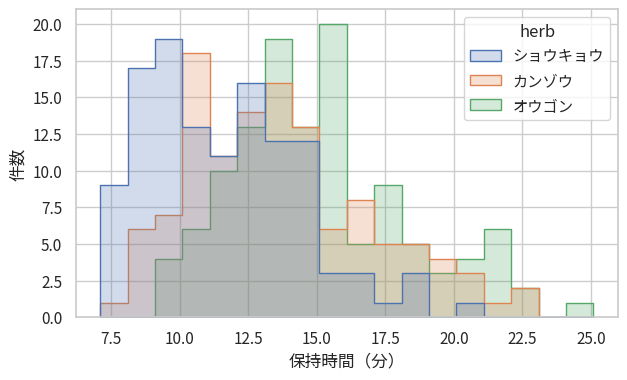

In [42]:
sns.set_theme(style='whitegrid')
setup_plotting()
fig, ax = plt.subplots()
sns.histplot(data=df,x='retention_min',hue='herb',bins=18,element='step',ax=ax)
ax.set(xlabel='保持時間（分）',ylabel='件数')
plt.show()

成分ごとの分布が重なっており、保持時間だけでは成分名は決まりません。色は凡例と合わせて読みます。

#### よくある間違い

- hueへ数値列を渡したときの意味を確認しない
- seabornをMatplotlibと独立した描画環境と思う

### 演習 SNS-01

分離度resolutionのヒストグラムを装置instrumentで色分けし、Figureをsns_01へ入れてください。軸名を分離度Rs・件数とし、凡例で装置が識別できることを確認します。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

histplotへdata、x、hue、axを渡します。

</details>

<details><summary>ヒント2</summary>

色分けした分布は重なるためelement="step"も使えます。

</details>

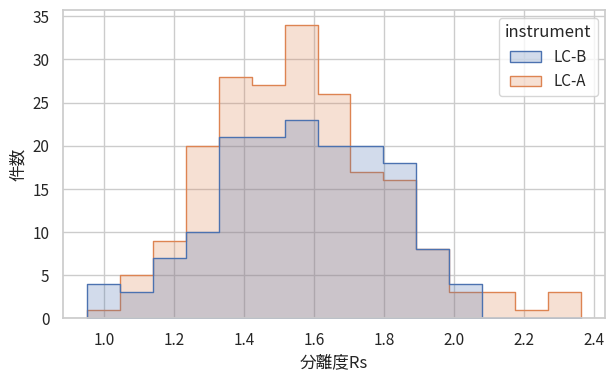

In [43]:
sns_01, ax = plt.subplots()
sns.histplot(data=df,x='resolution',hue='instrument',bins=15,element='step',ax=ax)
ax.set(xlabel='分離度Rs',ylabel='件数')
plt.show()

#### 考え方と結果の読み取り

装置ごとの分離度分布を見ます。分布の差は測定条件の違いを含む可能性があり、装置の劣化や優劣を証明しません。自動確認は図の構造のみです。

In [44]:
from learning import check_answer
check_answer('SNS-01', globals().get('sns_01'))

SNS-01：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- 凡例にLC-AとLC-Bがあるか
- 件数の差が棒の高さへ影響していないか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### SNS-02　カテゴリ比較と変数間の関係

目安：30分 / 前提：SNS-01

#### 学習目標

- 箱ひげ図を読む
- 色分け散布図で混在を確かめる

箱ひげ図の箱は第1四分位点から第3四分位点まで、箱の中の線は中央値です。seabornの既定のひげは箱の幅の1.5倍の範囲内にある端の値まで伸び、その外の点を個別に描きます。外側の点が自動的に誤測定を意味するわけではありません。

`boxplot()`はカテゴリごとの分布比較、`scatterplot()`は2つの数値の関係に向いています。散布図のhueに生薬名を指定すると、全体の傾向がカテゴリの混在によって見えていないかを点検できます。styleも指定すると点の形を変えられ、色だけに頼らず区別できます。

同じACNでも保持時間に幅があるのは、ほかの条件も変わっているためです。図で関係を見つけた後に、その原因を確かめるには、条件をそろえた実験など別の検討が必要です。

#### 例題（演習とは条件が異なります）

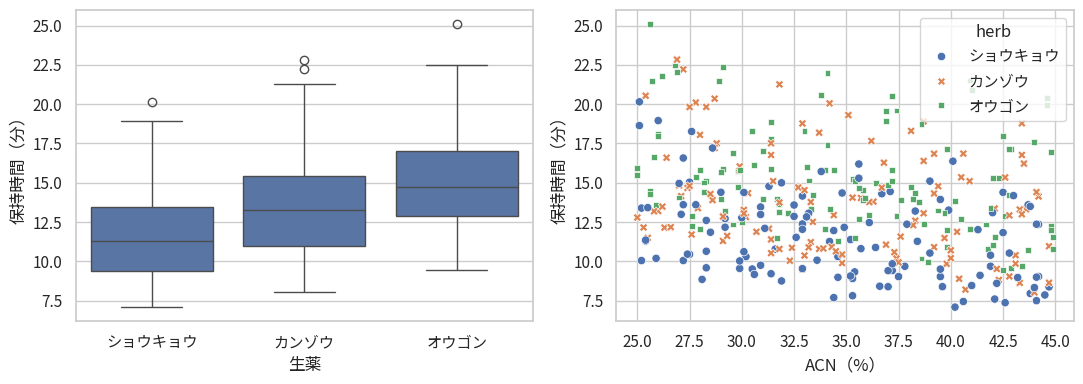

In [45]:
fig, axes = plt.subplots(1,2,figsize=(11,4))
sns.boxplot(data=df,x='herb',y='retention_min',ax=axes[0])
axes[0].set(xlabel='生薬',ylabel='保持時間（分）')
sns.scatterplot(data=df,x='acn',y='retention_min',hue='herb',style='herb',ax=axes[1])
axes[1].set(xlabel='ACN（%）',ylabel='保持時間（分）')
fig.tight_layout()
plt.show()

箱の中央値と広がりは別の情報です。散布図の色分けによって同じ生薬内の傾向も確かめます。

#### よくある間違い

- 箱の外の点を確認なしに削除する
- 異なる成分量の大小を薬効の大小と読む

### 演習 SNS-02

流速flowと保持時間retention_minの散布図を、生薬herbで色と形を分けて描き、Figureをsns_02に入れてください。「流速だけでは保持時間を説明しきれない」根拠を文章セルに書いてください。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

scatterplotのhueとstyleに同じherb列を渡せます。

</details>

<details><summary>ヒント2</summary>

同じ流速付近にある点の縦の広がりを見ます。

</details>

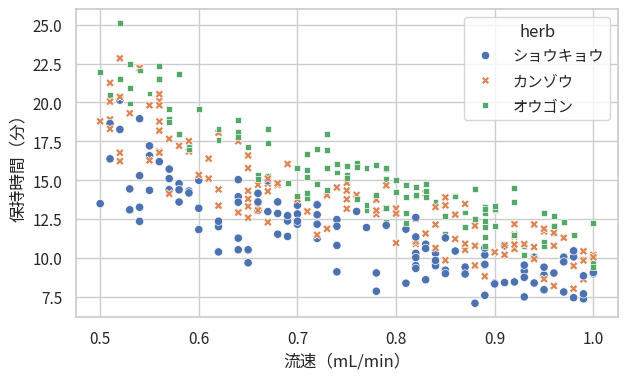

同じ流速でも保持時間が広がっており、成分やほかの条件も関係している。


In [46]:
sns_02, ax = plt.subplots()
sns.scatterplot(data=df,x='flow',y='retention_min',hue='herb',style='herb',ax=ax)
ax.set(xlabel='流速（mL/min）',ylabel='保持時間（分）')
plt.show()
print('同じ流速でも保持時間が広がっており、成分やほかの条件も関係している。')

#### 考え方と結果の読み取り

この生成データでは流速が大きいほど保持時間が短くなる傾向があります。一方、各成分や条件の違いが残るため、1つの直線で全点を説明できるわけではありません。

In [47]:
from learning import check_answer
check_answer('SNS-02', globals().get('sns_02'))

SNS-02：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- 凡例と点の形で生薬を区別できるか
- 観察された傾向と原因の断定を分けたか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### SNS-03　相関を一覧にして解釈する

目安：30分 / 前提：SNS-02・pandasの列選択

#### 学習目標

- 相関係数を読み取る
- ヒートマップを整える
- 作図ライブラリを使い分ける

相関係数は2つの数値の直線的な関係の強さと向きを、-1から1で表します。正なら一方が大きいと他方も大きい傾向、負なら逆方向です。0に近くても曲線的な関係がないとは限りません。

`corr()`で数値列どうしの相関行列を作り、`heatmap()`で値を色に変換します。対角線は同じ変数なので1です。`annot=True`で数値も表示すると色だけに頼らず読めます。`vmin=-1,vmax=1,center=0`で色の範囲を固定し、別の図とも比較しやすくします。

欠損がある場合、pandasは列の組ごとに両方の値が記録された行を使います。すべての係数が同じ行集合から計算されるとは限りません。相関が強くても因果関係や測定前の予測に使えることを保証しません。seabornで統計的な図を作り、Matplotlibで軸名や保存を調整すると役割を分担できます。

#### 例題（演習とは条件が異なります）

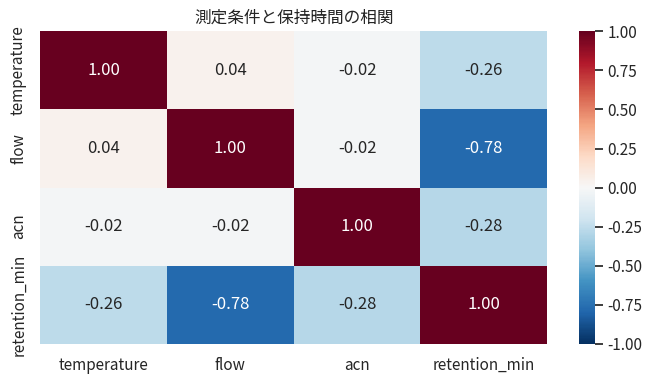

In [48]:
corr = df[['temperature','flow','acn','retention_min']].corr()
fig, ax = plt.subplots()
sns.heatmap(corr,annot=True,fmt='.2f',vmin=-1,vmax=1,center=0,cmap='RdBu_r',ax=ax)
ax.set_title('測定条件と保持時間の相関')
plt.tight_layout()
plt.show()

流速と保持時間の負の相関などを、数値の符号と大きさで読みます。温度に欠損があるため係数ごとに使用件数が違います。

#### よくある間違い

- 相関0をあらゆる関係がない証拠とする
- ピーク面積と成分量の相関を測定前の予測へ無条件に使う

### 演習 SNS-03

図を参考に「負の相関の意味」「相関から原因を決められない理由」「欠損によって使用行が変わること」を含む日本語60字以上の説明をsns_03に入れてください。自動確認は文字数だけで、内容は振り返りで確認します。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

流速と保持時間の関係を具体例にします。

</details>

<details><summary>ヒント2</summary>

ほかの測定条件も変わっていることを理由に加えます。

</details>

In [49]:
sns_03 = '流速と保持時間の負の相関は、流速が高い測定ほど保持時間が短い傾向を表す。ただし成分やほかの測定条件も変わるため、相関だけで原因は断定できない。温度には欠損があるので、係数の組ごとに使われる行も異なる。'
print(sns_03)

流速と保持時間の負の相関は、流速が高い測定ほど保持時間が短い傾向を表す。ただし成分やほかの測定条件も変わるため、相関だけで原因は断定できない。温度には欠損があるので、係数の組ごとに使われる行も異なる。


#### 考え方と結果の読み取り

観察した関係、因果の限界、欠損の扱いを分けて説明します。自動確認は語数や正確な意味を評価しないので、自分の文を図と照合します。

In [50]:
from learning import check_answer
check_answer('SNS-03', globals().get('sns_03'))

SNS-03：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- 負の相関を具体的な変数名で説明したか
- 原因の断定と欠損への言及を自分で確認したか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

## 5. scikit-learn

この章の準備セルを最初に実行してください。前の章の回答は使いません。例題は実行して変更する見本、演習は自分で書く問題です。

In [51]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display
from learning import check_answer
df = pd.read_csv('data/hplc.csv')
analytes = pd.read_csv('data/analytes.csv')
Path('outputs').mkdir(exist_ok=True)
import matplotlib.pyplot as plt
import seaborn as sns
from learning import setup_plotting
setup_plotting()
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, recall_score, confusion_matrix


### ML-01　予測に使える情報を選んで分割する

目安：30分 / 前提：pandas・NumPy・グラフの基礎

#### 学習目標

- 特徴量と目的変数を分ける
- 訓練・テストへ先に分割する

保持時間を測定前に予測する場面を考えます。予測の入力が特徴量X、予測したい答えが目的変数yです。連続した数値を予測する課題を回帰、区分を予測する課題を分類と呼びます。

入力には、測定前に分かる温度・流速・ACN比率・成分名・装置を使います。ピーク面積や測定済み分離度は測定後の情報です。保持時間そのものを入力すれば答えを見ていることになり、未知の測定へ使えません。

`train_test_split`はXとyの対応を保ったまま行を分け、訓練用とテスト用の4つを返します。test_size=0.2は20%をテストへ残す指定です。random_stateは分割を再現する初期値です。モデルも欠損補完も訓練データで学習し、テストは最後の評価用に保留します。同一検体の反復なら検体単位で分ける必要がありますが、この教材では各行が独立した架空検体です。

#### 例題（演習とは条件が異なります）

In [52]:
numeric = ['temperature', 'flow', 'acn']
categorical = ['analyte', 'instrument']
X = df[numeric + categorical]
y = df['retention_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('訓練:',X_train.shape,'テスト:',X_test.shape)
print('行の重複:',len(X_train.index.intersection(X_test.index)))

訓練: (288, 5) テスト: (72, 5)
行の重複: 0


360行のうち288行が訓練、72行がテストです。列数は5で、同じ行が両方に入っていません。

#### よくある間違い

- 全件で補完・標準化してから分ける
- 測定後の情報を測定前の予測に使う

### 演習 ML-01

同じ5つの特徴量から保持時間を予測するため、test_size=0.25、random_state=7で分割してください。ml_01にはX_train、X_test、y_train、y_testというキーの辞書で4つを入れ、テストが90行で重複がないことを確かめます。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

Xとyを同時にtrain_test_splitへ渡します。

</details>

<details><summary>ヒント2</summary>

返された4つを同じ名前のキーへ入れます。

</details>

In [53]:
numeric = ['temperature', 'flow', 'acn']
categorical = ['analyte', 'instrument']
X = df[numeric + categorical]
y = df['retention_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)
ml_01 = {'X_train':X_train,'X_test':X_test,'y_train':y_train,'y_test':y_test}
print(X_train.shape,X_test.shape)

(270, 5) (90, 5)


#### 考え方と結果の読み取り

25%の90行をテストへ残します。正解yと入力Xの行番号が対応していることも確認します。行数だけ合っていても、別々にランダム分割したXとyは対応を失うことがあります。

In [54]:
from learning import check_answer
check_answer('ML-01', globals().get('ml_01'))

ML-01：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- 各入力列は予測する時点で分かるか
- 同じ検体が訓練とテストに混ざる状況を説明できるか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### ML-02　前処理とモデルをPipelineにつなぐ

目安：40分 / 前提：ML-01

#### 学習目標

- 補完・標準化・カテゴリ変換を使う
- 訓練だけでfitする

欠損を中央値で埋めるSimpleImputer、各数値列の平均とばらつきをそろえるStandardScaler、文字カテゴリを0/1の列へ変えるOneHotEncoderを組み合わせます。未知のカテゴリにはhandle_unknown='ignore'を指定して停止を避けますが、未学習カテゴリを正確に予測できる保証ではありません。

ColumnTransformerは列の種類ごとに処理を分けます。Pipelineは処理を順につなぐ仕組みです。リストの各要素は `(処理名, 処理のオブジェクト)` という2つ組のタプルです。Ridgeは係数が極端に大きくならないよう抑えた線形回帰で、alphaがその強さです。

分割後に `model.fit(X_train,y_train)` を呼ぶと、補完値・標準化の基準・回帰係数を訓練だけで学びます。`predict(X_test)`は学んだ前処理をそのまま使います。テストへfitを呼びません。後の交差検証でもPipeline全体を渡せば、各分割の訓練部分だけで前処理を学習できます。

#### 例題（演習とは条件が異なります）

In [55]:
numeric = ['temperature', 'flow', 'acn']
categorical = ['analyte', 'instrument']
X = df[numeric + categorical]
y = df['retention_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preprocess = ColumnTransformer([
    ('num', Pipeline([('fill', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])
model = Pipeline([('prepare', preprocess), ('predict', Ridge(alpha=1.0))])
model.fit(X_train,y_train)
print('先頭3件の予測（分）:',model.predict(X_test.iloc[:3]))

先頭3件の予測（分）: [12.28517873 10.29718784  8.97392173]


補完・文字の変換を自分でテストへ繰り返す必要はありません。モデルが保持している訓練時の設定が使われます。

#### よくある間違い

- テストへfit_transformを呼ぶ
- カテゴリ列を単純な連番へ変えて大小関係を作る

### 演習 ML-02

このレッスンの例題と同じtest_size=0.2、random_state=42で分割し、Ridgeのalphaを10.0にしたPipelineを組み、訓練データにfitしてください。学習済みPipelineをml_02に入れ、テスト先頭5行への予測を表示します。前処理に使った中央値が訓練だけから求まっているか確認します。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

ColumnTransformerとPipelineの構成は例題を参考にし、alphaを変更します。

</details>

<details><summary>ヒント2</summary>

ml_02.fitへ渡すのはX_trainとy_trainだけです。

</details>

In [56]:
numeric = ['temperature', 'flow', 'acn']
categorical = ['analyte', 'instrument']
X = df[numeric + categorical]
y = df['retention_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preprocess = ColumnTransformer([
    ('num', Pipeline([('fill', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])
model = Pipeline([('prepare', preprocess), ('predict', Ridge(alpha=10.0))])
ml_02 = model.fit(X_train,y_train)
print(ml_02.predict(X_test.iloc[:5]))

[12.23137349 10.51068452  9.22952032 16.35802521 18.18379065]


#### 考え方と結果の読み取り

alphaを変えても前処理の学習範囲は変えません。5つの予測値は分単位です。alpha=10が常に優れるわけではなく、比較には後で学ぶ交差検証を使います。

In [57]:
from learning import check_answer
check_answer('ML-02', globals().get('ml_02'))

ML-02：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- fitへテストを渡していないか
- predictで欠損とカテゴリを処理できたか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### ML-03　単純な予測と比べて評価する

目安：30分 / 前提：ML-02

#### 学習目標

- ベースラインと比較する
- MAEとR²を読む

機械学習が役に立つかは、単純な予測と比べて確かめます。DummyRegressorはここでは訓練の保持時間の平均を、すべての測定へ返します。これが比較基準となるベースラインです。入力条件を使わなくても得られる予測より改善しているかを見ます。

MAEは予測と実際の差の絶対値を平均したものです。保持時間なら単位は分で、小さいほど誤差が小さくなります。R²は平均予測に対する改善を表す指標で、1が完全一致、0付近がテスト内の平均を返す程度です。負にもなり、その場合はその平均より悪い予測です。訓練平均を返すDummyのR²は必ず0ではありません。

例題は決めたRidgeを1回評価する学習用の実験です。テスト結果を見て条件を繰り返し変えると、テストも選択へ使ってしまいます。モデルの比較・選択は後の交差検証で行い、最後のテストは保留します。

#### 例題（演習とは条件が異なります）

In [58]:
numeric = ['temperature', 'flow', 'acn']
categorical = ['analyte', 'instrument']
X = df[numeric + categorical]
y = df['retention_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preprocess = ColumnTransformer([
    ('num', Pipeline([('fill', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])
model = Pipeline([('prepare', preprocess), ('predict', Ridge(alpha=1.0))])
model.fit(X_train,y_train)
pred = model.predict(X_test)
baseline = DummyRegressor(strategy='mean').fit(X_train,y_train)
base_pred = baseline.predict(X_test)
print('Ridge MAE（分）:',mean_absolute_error(y_test,pred))
print('平均予測 MAE（分）:',mean_absolute_error(y_test,base_pred))
print('R²:',r2_score(y_test,pred))

Ridge MAE（分）: 0.6354008963709941
平均予測 MAE（分）: 2.8584560185185186
R²: 0.9499070580954689


MAEをベースラインと同じテスト行で比べます。R²とMAEは異なる尺度なので、値の大小を直接比較しません。

#### よくある間違い

- R²を正解率と呼ぶ
- ベースラインだけ別のテストで評価する

### 演習 ML-03

test_size=0.25、random_state=42、Ridge alpha=1.0で、同じテスト行に対するRidgeと平均予測を比較してください。ml_03にmae、baseline_mae、r2の3キーで数値を入れます。MAEの単位とベースラインより改善したかを文章で説明してください。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

分割以降の前処理は訓練だけで学習します。

</details>

<details><summary>ヒント2</summary>

mean_absolute_errorへ実測値と予測値を渡します。

</details>

In [59]:
numeric = ['temperature', 'flow', 'acn']
categorical = ['analyte', 'instrument']
X = df[numeric + categorical]
y = df['retention_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
preprocess = ColumnTransformer([
    ('num', Pipeline([('fill', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])
model = Pipeline([('prepare', preprocess), ('predict', Ridge(alpha=1.0))])
model.fit(X_train,y_train)
pred = model.predict(X_test)
baseline = DummyRegressor(strategy='mean').fit(X_train,y_train)
base_pred = baseline.predict(X_test)
ml_03 = {'mae':mean_absolute_error(y_test,pred),'baseline_mae':mean_absolute_error(y_test,base_pred),'r2':r2_score(y_test,pred)}
print(ml_03)

{'mae': 0.6791374004876255, 'baseline_mae': 2.8403101234567902, 'r2': 0.9438015821630136}


#### 考え方と結果の読み取り

この架空データには条件と保持時間の関係を入れてあるため、Ridgeは平均予測よりMAEを下げられます。小さな誤差に見えても、実業務に必要な精度かはこの教材だけで決められません。

In [60]:
from learning import check_answer
check_answer('ML-03', globals().get('ml_03'))

ML-03：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- MAEを分という単位で説明したか
- 同じテスト行で2つのモデルを比較したか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### ML-04　分類の正解率と見逃しを読む

目安：35分 / 前提：ML-03

#### 学習目標

- 回帰と分類を区別する
- 混同行列とrecallを読む

分離度が1.5以上かという学習用の区分を作ります。`(df['resolution'] >= 1.5).astype(int)`でTrueを1、Falseを0へ変えます。これは二値分類の練習であり、実試料の規格適合や測定法の妥当性を判定するものではありません。

LogisticRegressionは名前にRegressionがありますが、ここでは分類に使います。stratify=yは分割後も0と1の割合を近く保つ指定です。DummyClassifierは訓練で多い方のクラスを常に予測するベースラインにします。

accuracyは全体の正解割合です。recallは実際に1だった行のうち、1と予測できた割合です。この定義では見逃しは「実際は分離度区分1なのに0と予測する」ことです。混同行列は行が実際、列が予測で、labels=[0,1]なら左上が0を0、右下が1を1と予測した件数です。クラスの意味を逆にするとrecallの意味も変わるので、値だけを読まないでください。

`zero_division=0`は、実際のクラス1が0件で再現率を計算できない場合に0を返す指定です。その場合の0は「全件見逃した」と同じ意味ではなく、評価対象の1がいないことを併せて報告します。

#### 例題（演習とは条件が異なります）

In [61]:
numeric = ['temperature', 'flow', 'acn']
categorical = ['analyte', 'instrument']
X = df[numeric + categorical]
y = (df['resolution'] >= 1.5).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
preprocess = ColumnTransformer([
    ('num', Pipeline([('fill', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])
model = Pipeline([('prepare', preprocess), ('predict', LogisticRegression(max_iter=1000))])
model.fit(X_train,y_train)
pred = model.predict(X_test)
baseline = DummyClassifier(strategy='most_frequent').fit(X_train,y_train)
base_pred = baseline.predict(X_test)
print('正解率:',accuracy_score(y_test,pred))
print('クラス1の再現率:',recall_score(y_test,pred,zero_division=0))
print('混同行列：行=実際、列=予測、順序0,1')
print(confusion_matrix(y_test,pred,labels=[0,1]))

正解率: 0.75
クラス1の再現率: 0.7857142857142857
混同行列：行=実際、列=予測、順序0,1
[[21  9]
 [ 9 33]]


左下は実際1・予測0の件数です。精度の評価では正解率だけでなく、どちらの取り違えが起きたかを読みます。

#### よくある間違い

- クラス1の意味を決めずrecallを読む
- 正解率が高ければ両方のクラスで良いと考える

### 演習 ML-04

同じ入力列を使い、test_size=0.25、random_state=42、stratify=yで分類してください。ml_04にaccuracy、baseline_accuracy、recall、matrix（labels=[0,1]の混同行列）の4キーを入れ、取り違えの方向を説明します。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

LogisticRegressionのPipelineとDummyClassifierを同じ訓練行で学習します。

</details>

<details><summary>ヒント2</summary>

confusion_matrixの行が実際、列が予測です。

</details>

In [62]:
numeric = ['temperature', 'flow', 'acn']
categorical = ['analyte', 'instrument']
X = df[numeric + categorical]
y = (df['resolution'] >= 1.5).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
preprocess = ColumnTransformer([
    ('num', Pipeline([('fill', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])
model = Pipeline([('prepare', preprocess), ('predict', LogisticRegression(max_iter=1000))])
model.fit(X_train,y_train)
pred = model.predict(X_test)
baseline = DummyClassifier(strategy='most_frequent').fit(X_train,y_train)
base_pred = baseline.predict(X_test)
ml_04 = {'accuracy':accuracy_score(y_test,pred),'baseline_accuracy':accuracy_score(y_test,base_pred),'recall':recall_score(y_test,pred,zero_division=0),'matrix':confusion_matrix(y_test,pred,labels=[0,1])}
print(ml_04)

{'accuracy': 0.7666666666666667, 'baseline_accuracy': 0.5888888888888889, 'recall': 0.7924528301886793, 'matrix': array([[27, 10],
       [11, 42]])}


#### 考え方と結果の読み取り

90件のテストの正解率と、実際1の中での再現率を別に評価します。混同行列の左下と右上は逆の間違いです。実務の重大な見逃しがどちらかは目的変数の定義次第なので、この教材のクラス定義を明記します。

In [63]:
from learning import check_answer
check_answer('ML-04', globals().get('ml_04'))

ML-04：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- 混同行列の合計が90か
- どのクラスのrecallを計算したかを言葉にしたか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### ML-05　訓練に合いすぎるモデルを見つける

目安：35分 / 前提：ML-04

#### 学習目標

- 訓練誤差と検証誤差を比べる
- 最終テストを選択に使わない

訓練データへ細かく合わせすぎて、未知のデータで誤差が大きくなる状態を過学習と呼びます。決定木は条件を枝分かれさせて予測するモデルです。max_depthは枝分かれの深さの上限で、Noneなら深さの制限を置きません。

ここでは最初に確保したテストを使わず、訓練データの中をさらに学習用と検証用へ分けます。深さ2と無制限の木を同じ分割で比較し、訓練MAEと検証MAEを並べます。訓練だけ極端に良くても、モデル選択の根拠にはなりません。

`for depth in [2,None]:`は深さの候補を一つずつ取り出す繰り返しです。`rows=[]`で空のリストを作り、appendで結果の辞書を追加して最後に表へ変えます。各候補でPipelineを新しく作り、補完の基準も学習側だけから学びます。有限の検証データなので、たった1回の分割でモデルの優劣が固定されるわけではありません。

#### 例題（演習とは条件が異なります）

In [64]:
numeric = ['temperature', 'flow', 'acn']
categorical = ['analyte', 'instrument']
X = df[numeric + categorical]
y = df['retention_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_fit, X_valid, y_fit, y_valid = train_test_split(X_train,y_train,test_size=0.25,random_state=7)
rows = []
for depth in [2,None]:
    preprocess = ColumnTransformer([
        ('num', Pipeline([('fill', SimpleImputer(strategy='median')),
                          ('scale', StandardScaler())]), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
    ])
    model = Pipeline([('prepare', preprocess), ('predict', DecisionTreeRegressor(max_depth=depth,random_state=42))])
    model.fit(X_fit,y_fit)
    rows.append({'depth':str(depth),'train_mae':mean_absolute_error(y_fit,model.predict(X_fit)),
                 'valid_mae':mean_absolute_error(y_valid,model.predict(X_valid))})
comparison = pd.DataFrame(rows)
display(comparison)

,depth,train_mae,valid_mae
0,2,1.641014,1.910723
1,None,0.000000,0.914819


無制限の木は訓練誤差をほぼゼロにできても、検証誤差は残ります。必ず浅い木より悪くなるわけではない点も表で確かめます。

#### よくある間違い

- 訓練誤差が最小のモデルを必ず採用する
- 深さを変えるたびテストを見て最終評価に使う

### 演習 ML-05

深さ3とNoneの決定木を、最初にtest_size=0.2・random_state=42でテストを保留し、残りをtest_size=0.25・random_state=7で学習用と検証用に分けて比較してください。ml_05をdepth・train_mae・valid_maeの2行の表にし、どの誤差を選択の参考にするか文章で説明します。最終テストは使いません。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

例題の候補リストを[3,None]へ変更します。

</details>

<details><summary>ヒント2</summary>

検証用はX_trainから分け、X_testは参照しません。

</details>

In [65]:
numeric = ['temperature', 'flow', 'acn']
categorical = ['analyte', 'instrument']
X = df[numeric + categorical]
y = df['retention_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_fit, X_valid, y_fit, y_valid = train_test_split(X_train,y_train,test_size=0.25,random_state=7)
rows = []
for depth in [3,None]:
    preprocess = ColumnTransformer([
        ('num', Pipeline([('fill', SimpleImputer(strategy='median')),
                          ('scale', StandardScaler())]), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
    ])
    model = Pipeline([('prepare', preprocess), ('predict', DecisionTreeRegressor(max_depth=depth,random_state=42))])
    model.fit(X_fit,y_fit)
    rows.append({'depth':str(depth),'train_mae':mean_absolute_error(y_fit,model.predict(X_fit)),
                 'valid_mae':mean_absolute_error(y_valid,model.predict(X_valid))})
comparison = pd.DataFrame(rows)
ml_05 = comparison
display(ml_05)

,depth,train_mae,valid_mae
0,3,1.218159,1.834238
1,None,0.000000,0.914819


#### 考え方と結果の読み取り

訓練誤差と検証誤差の差から、訓練への当てはまりが未知データへそのまま移らないことが分かります。選択は検証誤差を参考にし、最終テストは選択が終わるまで保留します。

In [66]:
from learning import check_answer
check_answer('ML-05', globals().get('ml_05'))

ML-05：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- 最終テストをこの比較で使っていないか
- 無制限の木の訓練誤差と検証誤差の差を説明したか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### ML-06　交差検証をしてから最後のテストへ

目安：40分 / 前提：ML-05

#### 学習目標

- Pipelineを交差検証する
- CVと最終テストの役割を区別する

交差検証は、訓練データを複数の組に分け、1組ずつ検証に回す方法です。cv=5では5通りを評価します。各回で前処理を学び直すため、配列へ一括で補完したものではなくPipeline全体を渡します。cross_val_scoreは大きいほど良い評価値を返す設計なので、MAEは負の値として返ります。先頭のマイナス記号で正の誤差へ戻します。

候補のalphaを訓練内のCV平均で比較し、選んだ設定を全訓練データにfitします。その後に初めて、保留したテストで評価します。CVの平均と標準偏差は分割による変動の目安で、将来の誤差を保証する区間ではありません。

結果を再現するために、分割、特徴量、前処理、モデル設定、指標を記録します。教材で何度も試すとテストに慣れてしまう点にも注意してください。実際の最終評価では、本当に選択へ使っていない測定が必要です。

例題ではalpha=1の1候補だけを評価します。演習では3候補を比較してから最終テストへ進みます。

`scoring='neg_mean_absolute_error'`は評価指標として負のMAEを選ぶ指定です。既定の指標に任せず、比較したい量を明示します。

#### 例題（演習とは条件が異なります）

In [67]:
numeric = ['temperature', 'flow', 'acn']
categorical = ['analyte', 'instrument']
X = df[numeric + categorical]
y = df['retention_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preprocess = ColumnTransformer([
    ('num', Pipeline([('fill', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])
model = Pipeline([('prepare', preprocess), ('predict', Ridge(alpha=1.0))])
scores = -cross_val_score(model,X_train,y_train,cv=5,scoring='neg_mean_absolute_error')
print('各分割のMAE（分）:',scores)
print('平均:',scores.mean(),'標準偏差:',scores.std())
model.fit(X_train,y_train)
print('選択後の最終テストMAE（分）:',mean_absolute_error(y_test,model.predict(X_test)))


各分割のMAE（分）: [0.59711545 0.49223823 0.72368886 0.66850381 0.58600773]
平均: 0.6135108154287419 標準偏差: 0.07860750379410043
選択後の最終テストMAE（分）: 0.6354008963709941


5つのCV誤差は少しずつ異なります。最終テストMAEがCV平均と完全に一致しないのは、別の測定を評価しているためです。

#### よくある間違い

- 負のMAEをそのまま小さいほど良いと読む
- テストで選んだalphaをテストで最終評価する

### 演習 ML-06

最初にtest_size=0.2、random_state=42で分割します。alpha候補0.1、1.0、10.0を訓練データだけの5分割CVで比較してください。CV平均MAEが最小のalphaを選び、全訓練で再学習し最後にテストを1度評価します。ml_06はcv（alpha・maeの3行表）、best_alpha、test_maeの辞書にします。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

候補ごとにPipelineを作り、cross_val_scoreへX_train,y_trainだけを渡します。

</details>

<details><summary>ヒント2</summary>

mae列が最小の行はidxmin()で取り出せます。

</details>

In [68]:
numeric = ['temperature', 'flow', 'acn']
categorical = ['analyte', 'instrument']
X = df[numeric + categorical]
y = df['retention_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rows = []
for alpha in [0.1,1.0,10.0]:
    preprocess = ColumnTransformer([
        ('num', Pipeline([('fill', SimpleImputer(strategy='median')),
                          ('scale', StandardScaler())]), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
    ])
    model = Pipeline([('prepare', preprocess), ('predict', Ridge(alpha=alpha))])
    scores = -cross_val_score(model,X_train,y_train,cv=5,scoring='neg_mean_absolute_error')
    rows.append({'alpha':alpha,'mae':scores.mean()})
cv = pd.DataFrame(rows)
best_alpha = cv.loc[cv['mae'].idxmin(),'alpha']
preprocess = ColumnTransformer([
    ('num', Pipeline([('fill', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])
model = Pipeline([('prepare', preprocess), ('predict', Ridge(alpha=best_alpha))])
model.fit(X_train,y_train)
ml_06 = {'cv':cv,'best_alpha':best_alpha,'test_mae':mean_absolute_error(y_test,model.predict(X_test))}
display(ml_06['cv'])
print('選んだalpha:',ml_06['best_alpha'],'最終テストMAE（分）:',ml_06['test_mae'])

,alpha,mae
0,0.1,0.616189
1,1.0,0.613511
2,10.0,0.608584


選んだalpha: 10.0 最終テストMAE（分）: 0.6668507344890761


#### 考え方と結果の読み取り

選択の根拠はCV表の平均MAEです。最終テストの結果を見てalphaを選び直すと、そのテストは最終評価として使えなくなります。CVに渡したPipelineが各回で前処理を学習することが漏洩防止の要点です。

In [69]:
from learning import check_answer
check_answer('ML-06', globals().get('ml_06'))

ML-06：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- alpha選択と最終評価に別のデータを使ったか
- CVのばらつきを保証と誤解していないか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

## 6. 総合演習

この章の準備セルを最初に実行してください。前の章の回答は使いません。例題は実行して変更する見本、演習は自分で書く問題です。

In [70]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display
from learning import check_answer
df = pd.read_csv('data/hplc.csv')
analytes = pd.read_csv('data/analytes.csv')
Path('outputs').mkdir(exist_ok=True)
import matplotlib.pyplot as plt
import seaborn as sns
from learning import setup_plotting
setup_plotting()
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, recall_score, confusion_matrix


### ALL-01　測定表を整えて集計を残す

目安：35分 / 前提：pandasからscikit-learnまで

#### 学習目標

- 加工前後の行数を記録する
- 結合と集計を組み合わせる

ここからは道具ごとの練習をつなぎます。最初に「成分量が記録された測定を生薬別に要約する」と目的を決めます。使う列と欠損の扱いを先に決めると、必要以上の行を落とさずに済みます。

読み込み、欠損数の確認、必要な行の選択、マスタ結合、集計、保存の順に進みます。中間の表の名前を分けると、どこで件数が変わったかを追えます。平均と有効件数を並べ、保存後には列名と値を読み直します。

実データでは測定単位や抽出条件がそろっているかも重要です。架空データで動いた処理をそのまま実測へ適用せず、1行が何を表すか、欠損がなぜ生じたか、マスタが一意かを確認してから進めます。

#### 例題（演習とは条件が異なります）

In [71]:
raw = pd.read_csv('data/hplc.csv')
print('元の行数:',len(raw))
clean = raw.dropna(subset=['content_mg_g']).copy()
print('残った行数:',len(clean))
summary = clean.groupby('herb')['content_mg_g'].agg(['count','mean'])
display(summary)

元の行数: 360
残った行数: 336


,count,mean
herb,,
オウゴン,113,15.941319
カンゾウ,109,12.087275
ショウキョウ,114,7.900219


除外した行数と生薬別の件数を見ます。成分量の平均だけ保存するより、どれだけの測定を使ったかが分かります。

#### よくある間違い

- 必要のない列の欠損まで理由なく除外する
- 保存した表から単位や処理内容が分からない

### 演習 ALL-01

CSVを新たに読み、成分量が欠損した行を除き、準備セルのanalytes（data/analytes.csvの成分マスタ）をmany_to_oneで結合してください。成分類class別のcontent_mg_gのcountとmeanを表all_01に入れ、outputs/final_summary.csvへ分類名を通常列として保存します。除外行数も表示してください。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

成分量の欠損だけを除外します。

</details>

<details><summary>ヒント2</summary>

groupby後にagg(["count","mean"])を使います。

</details>

In [72]:
raw = pd.read_csv('data/hplc.csv')
clean = raw.dropna(subset=['content_mg_g']).copy()
joined = clean.merge(analytes,on='analyte',how='left',validate='many_to_one')
all_01 = joined.groupby('class')['content_mg_g'].agg(['count','mean'])
all_01.reset_index().to_csv('outputs/final_summary.csv',index=False)
print('除外行数:',len(raw)-len(clean))
display(pd.read_csv('outputs/final_summary.csv'))

除外行数: 24


,class,count,mean
0,サポニン類,109,12.087275
1,ジンゲロール類,114,7.900219
2,フラボノイド類,113,15.941319


#### 考え方と結果の読み取り

24行を除外し336行を集計しました。生薬ごとに別の成分なので、この平均から成分類の薬効や品質を直接比較できません。除外と結合の手順を残すと、あとで別の扱いを試せます。

In [73]:
from learning import check_answer
check_answer('ALL-01', globals().get('all_01'))

ALL-01：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- 入力CSVを上書きしていないか
- 行数・欠損・結合キー・単位を記録したか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### ALL-02　図と文章で結果を伝える

目安：35分 / 前提：ALL-01（回答済みでなくてもよい）

#### 学習目標

- 問いに合う図を選ぶ
- 根拠と限界を文章にする

グラフを作る前に、答えたい問いを1つに絞ります。「流速と保持時間にどのような関係があるか」なら散布図、「成分ごとの広がりはどう違うか」なら箱ひげ図が向いています。見た目を整えることに加え、どの行を使った図かを説明します。

説明文は、見えた傾向、図のどこが根拠か、ここからは分からないことの順で書くと伝わります。例えば「同じ流速でも縦に点が広がる」という観察は図で確認できます。一方、「装置が原因だ」はこの図だけでは確認できません。

今回の図は架空の生成式の結果です。実測の機構を証明するものではありません。色分け・形・軸の単位を整え、図だけを受け取った人にも比較対象が分かるようにします。

#### 例題（演習とは条件が異なります）

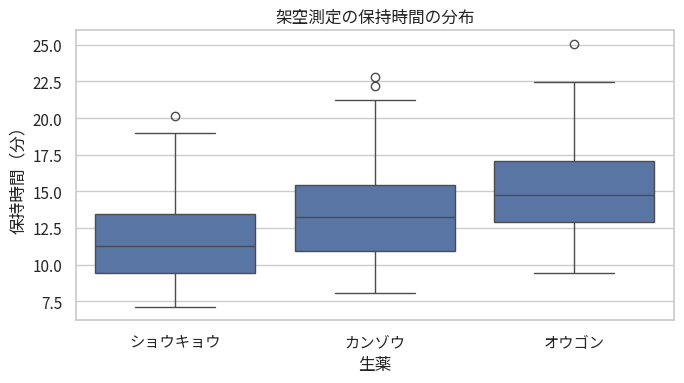

In [74]:
fig, ax = plt.subplots()
sns.boxplot(data=df,x='herb',y='retention_min',ax=ax)
ax.set(xlabel='生薬',ylabel='保持時間（分）',title='架空測定の保持時間の分布')
fig.tight_layout()
plt.show()

中央値と箱の広がりを分けて読みます。異なる条件を混ぜた分布なので、成分の違いだけの効果ではありません。

#### よくある間違い

- 図の装飾に集中し問いが不明になる
- 観察事実と仮説を同じ強さで断定する

### 演習 ALL-02

準備セルのdf（欠損除外前の360行）を使います。ACNと保持時間の散布図を生薬別に色・形で分け、outputs/final_plot.pngへ保存してください。all_02をfigureとreportの辞書にし、reportに「傾向・根拠・限界」を含む60字以上の説明を書いてください。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

scatterplotのhueとstyleをherbにします。

</details>

<details><summary>ヒント2</summary>

図を見て、同じACNでのばらつきにも言及します。

</details>

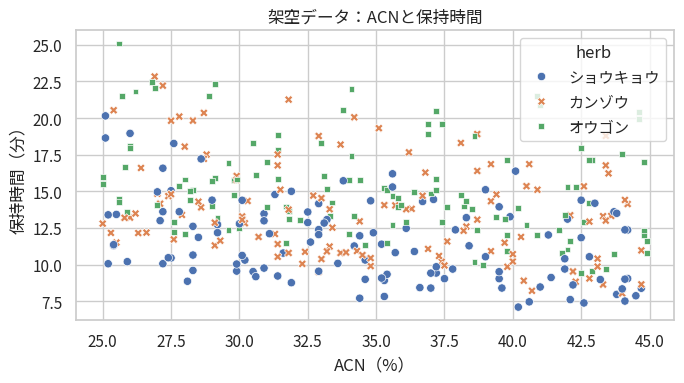

ACNが高い測定では保持時間が短い傾向がある。同じACNでも点が縦に広がり、生薬やほかの測定条件の違いも見える。この架空データの観察だけから実試料の保持機構や最適条件は断定できない。


In [75]:
fig, ax = plt.subplots()
sns.scatterplot(data=df,x='acn',y='retention_min',hue='herb',style='herb',ax=ax)
ax.set(xlabel='ACN（%）',ylabel='保持時間（分）',title='架空データ：ACNと保持時間')
fig.tight_layout()
fig.savefig('outputs/final_plot.png',dpi=150)
plt.show()
all_02 = {'figure':fig,'report':'ACNが高い測定では保持時間が短い傾向がある。同じACNでも点が縦に広がり、生薬やほかの測定条件の違いも見える。この架空データの観察だけから実試料の保持機構や最適条件は断定できない。'}
print(all_02['report'])

#### 考え方と結果の読み取り

横軸ACNが高い側で保持時間が短くなる傾向を述べ、同じACNでも点が縦に広がることを根拠に、ほかの条件も関わると説明しています。自動確認はFigure・文章・保存ファイルの存在に限られます。読み取り内容は図と照合して確かめてください。

In [76]:
from learning import check_answer
check_answer('ALL-02', globals().get('all_02'))

ALL-02：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- 文章の根拠を図上で示せるか
- 実試料への一般化や因果を断定していないか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。

### ALL-03　予測の結果と限界を報告する

目安：40分 / 前提：ML-06・ALL-02（回答済みでなくてもよい）

#### 学習目標

- 一連の分析を再現する
- ベースライン・CV・テストを報告する
- 実測へ移す前の課題を書く

最後は保持時間の予測を、読み込みから報告までつなぎます。測定前に分かる5列だけを選び、20%を最終テストに残します。中央値補完・標準化・カテゴリ変換をPipelineへ入れ、訓練だけで5分割CVをします。モデル設定はここではalpha=1.0に固定し、CVでテスト結果を選びません。

CVで大きな不具合がないか確認してから、訓練全体で学習し、最終テストを1度だけ評価します。同じテスト行へ訓練平均のベースラインも出し、MAEを比較します。図には実際の保持時間と予測値を描き、同じなら乗る対角線も加えます。

報告には入力、分割、指標と単位、ベースラインとの差、限界を含めます。今回は架空の生成式を学ぶ結果です。実測へ進むなら検体・ロットの重複、装置や日付の違い、将来のデータでの評価を考える必要があります。

例題は予測値と架空の実測値の図を作ります。演習はCV・数値評価・報告をまとめます。固定したモデル設定で評価手順を一通り実行する練習です。

解答の文章はf文字列で数値を埋め込みます。例えば `f'MAEは{mae:.3f}分'` は変数maeを小数3桁で表示します。報告は手で数値を書いても構いません。

#### 例題（演習とは条件が異なります）

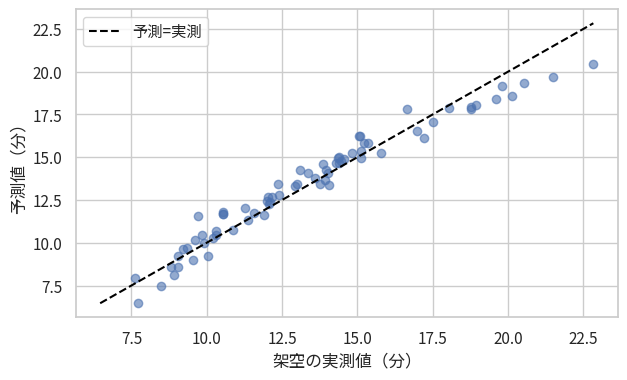

In [77]:
numeric = ['temperature', 'flow', 'acn']
categorical = ['analyte', 'instrument']
X = df[numeric + categorical]
y = df['retention_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preprocess = ColumnTransformer([
    ('num', Pipeline([('fill', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])
model = Pipeline([('prepare', preprocess), ('predict', Ridge(alpha=1.0))])
model.fit(X_train,y_train)
pred = model.predict(X_test)
baseline = DummyRegressor(strategy='mean').fit(X_train,y_train)
base_pred = baseline.predict(X_test)
fig, ax = plt.subplots()
ax.scatter(y_test,pred,alpha=0.6)
limits = [min(y_test.min(),pred.min()),max(y_test.max(),pred.max())]
ax.plot(limits,limits,linestyle='--',color='black',label='予測=実測')
ax.set(xlabel='架空の実測値（分）',ylabel='予測値（分）')
ax.legend()
plt.show()

対角線に近いほど誤差が小さく、上側では過大予測、下側では過小予測です。誤差の大きさが保持時間によって変わらないかも確認します。

#### よくある間違い

- CVとテストの値を混ぜて一つの精度と呼ぶ
- 架空データの良い性能を実試料での保証とする

### 演習 ALL-03

CSVを新たに読み、測定前の5列から保持時間を予測してください。20%をrandom_state=42で保留し、Ridge alpha=1のPipelineを訓練だけの5分割CVで評価します。全訓練で学習後、最終テストと訓練平均ベースラインのMAEを求めます。all_03にcv_mae（5値）、test_mae、baseline_mae、report（入力・分割・単位・比較・限界を含む100字以上）を入れてください。

使用データ：`data/hplc.csv`（架空測定データ）、結合には `data/analytes.csv`。この章の準備セルを先に実行します。ほかの演習への依存はありません。

<details><summary>ヒント1</summary>

前処理を先に全データへ適用しないでください。

</details>

<details><summary>ヒント2</summary>

CVにはX_trainだけ、最後のpredictにはX_testを使います。

</details>

In [78]:
df = pd.read_csv('data/hplc.csv')
numeric = ['temperature', 'flow', 'acn']
categorical = ['analyte', 'instrument']
X = df[numeric + categorical]
y = df['retention_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preprocess = ColumnTransformer([
    ('num', Pipeline([('fill', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])
model = Pipeline([('prepare', preprocess), ('predict', Ridge(alpha=1.0))])
scores = -cross_val_score(model,X_train,y_train,cv=5,scoring='neg_mean_absolute_error')
model.fit(X_train,y_train)
pred = model.predict(X_test)
baseline = DummyRegressor(strategy='mean').fit(X_train,y_train)
test_mae = mean_absolute_error(y_test,pred)
baseline_mae = mean_absolute_error(y_test,baseline.predict(X_test))
report = f'測定前に分かる温度・流速・ACN・成分名・装置から保持時間を予測した。360行の20%を保留し、残りの訓練内で5分割CVを行った。CV平均MAEは{scores.mean():.3f}分、最終テストMAEは{test_mae:.3f}分、訓練平均のベースラインは{baseline_mae:.3f}分だった。生成式を持つ架空データでの結果なので、実試料への精度は保証されない。実測では同一検体やロットの重複を考えた分割と、別の日の測定による検証が必要である。'
all_03 = {'cv_mae':scores,'test_mae':test_mae,'baseline_mae':baseline_mae,'report':report}
print('各分割MAE（分）:',scores)
print(report)

各分割MAE（分）: [0.59711545 0.49223823 0.72368886 0.66850381 0.58600773]
測定前に分かる温度・流速・ACN・成分名・装置から保持時間を予測した。360行の20%を保留し、残りの訓練内で5分割CVを行った。CV平均MAEは0.614分、最終テストMAEは0.635分、訓練平均のベースラインは2.858分だった。生成式を持つ架空データでの結果なので、実試料への精度は保証されない。実測では同一検体やロットの重複を考えた分割と、別の日の測定による検証が必要である。


#### 考え方と結果の読み取り

入力時点を守り、分割後のPipelineで前処理を学習しました。CVと最終テストは別の値として報告し、ベースラインも同じテストで比較しています。MAEは平均の誤差なので、最大誤差や業務上の許容幅の判断を別途行う必要があります。

In [79]:
from learning import check_answer
check_answer('ALL-03', globals().get('all_03'))

ALL-03：自動確認の条件を満たしました。解釈・グラフは下の観点でも確認しましょう。


True

#### 自己確認と振り返り

- 前処理のfitへテストが混ざっていないか
- 報告に単位・比較・限界を含めたか
- 自分の仕事に適用する前に何を追加検証するか

グラフは軸・単位・比較対象・凡例、文章は根拠と限界を自分でも点検します。自動確認だけで解釈の正しさは判定できません。